# Анализ продаж и пользовательской активности маркетплейса


**Цель проекта** - разработка аналитического дашбода для маркетплеса, который позволит отслеживать ключевые показатели продаж, пользовательской активности, качества товаров и эфективности работы платформы.

## Этап предобработки данных 

**Выполненные задачи**

1. Загрузка данных из CSV
* проверить размеры и предварительно изучите столбцы
2. Подготовка данных
* удалить явные и неявные дубликаты
* обработать пропуски: удалить или заполнить логичными значениями
* преобразовать типы данных
* категоризировать признаки
* найти и исправить логические ошибки (отрицательные цены, невозможные значения)
3. Исследовательский анализ
* изучить распределения признаков
* найти аномалии и выбросы
* выполнить корреляционный анализ
* сделать визуализацию с помощью гистограмм, линейных графиков по времени и так далее
4. Подготовка данных к выгрузке
* выгрузить данные


###  Подключение и загрузка данных

In [1]:
# Импортируем библиотеки

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Функция для загрузки таблицы из CSV

def load_table(table_name):
    print(f"Загружаем таблицу {table_name}...")
    file_path = f"{table_name}.csv"
    df = pd.read_csv(file_path)
    print(f"Таблица {table_name} загружена, размер: {df.shape}")
    return df

# Список ключевых таблиц
tables = ['orders', 'order_items', 'products', 'users', 'categories', 'transactions', 'reviews']

In [3]:
# Загружаем все таблицы в словарь
data = {}
for tbl in tables:
    data[tbl] = load_table(tbl)



Загружаем таблицу orders...
Таблица orders загружена, размер: (505400, 5)
Загружаем таблицу order_items...
Таблица order_items загружена, размер: (1516751, 5)
Загружаем таблицу products...
Таблица products загружена, размер: (52100, 7)
Загружаем таблицу users...
Таблица users загружена, размер: (111300, 7)
Загружаем таблицу categories...
Таблица categories загружена, размер: (1800, 3)
Загружаем таблицу transactions...
Таблица transactions загружена, размер: (811200, 5)
Загружаем таблицу reviews...
Таблица reviews загружена, размер: (310100, 6)


### Предобработка

In [4]:
# Удаление дубликатов
total_dups = 0
for name, df in data.items():
    dups = df.duplicated().sum()
    total_dups += dups
    print(f'{name}: {dups} дубликатов')
    if dups > 0:
        df.drop_duplicates(inplace=True)

if total_dups == 0:
    print("Во всех таблицах дубликаты не найдены")

orders: 0 дубликатов
order_items: 0 дубликатов
products: 0 дубликатов
users: 0 дубликатов
categories: 0 дубликатов
transactions: 0 дубликатов
reviews: 0 дубликатов
Во всех таблицах дубликаты не найдены


In [5]:
# Преобразование дат
data['orders']['order_date'] = pd.to_datetime(data['orders']['order_date'])
data['reviews']['review_date'] = pd.to_datetime(data['reviews']['review_date'])
data['transactions']['transaction_date'] = pd.to_datetime(data['transactions']['transaction_date'])
data['users']['registration_date'] = pd.to_datetime(data['users']['registration_date'])

In [6]:
# Исправление отрицательных цен в products
neg_prices = data['products'][data['products']['price'] < 0].shape[0]
if neg_prices > 0:
    data['products'].loc[data['products']['price'] < 0, 'price'] = 0
print(f'products: исправлено {neg_prices} отрицательных цен')

products: исправлено 0 отрицательных цен


In [7]:
# Проверка пропусков
for name, df in data.items():
    print(f"\n{name} — пропущенные значения:")
    print(df.isna().sum())


orders — пропущенные значения:
order_id        0
buyer_id        0
order_date      0
status          0
total_amount    0
dtype: int64

order_items — пропущенные значения:
order_item_id          0
order_id               0
product_id             0
quantity               0
price_at_order_time    0
dtype: int64

products — пропущенные значения:
product_id        0
title             0
description       0
category_id       0
price             0
stock_quantity    0
seller_id         0
dtype: int64

users — пропущенные значения:
user_id              0
name                 0
email                0
phone                0
user_type            0
registration_date    0
is_active            0
dtype: int64

categories — пропущенные значения:
category_id             0
name                    0
parent_category_id    885
dtype: int64

transactions — пропущенные значения:
transaction_id      0
user_id             0
amount              0
transaction_type    0
transaction_date    0
dtype: int64

reviews —

In [8]:
# Категоризация рейтинга в reviews
def categorize_rating(r):
    if r >= 4.5:
        return 'High'
    elif r >= 4:
        return 'Medium'
    else:
        return 'Low'

data['reviews']['rating_category'] = data['reviews']['rating'].apply(categorize_rating)
print('reviews: добавлен столбец rating_category')

reviews: добавлен столбец rating_category


### Исследовательский анализ

In [9]:
def eda(df, columns):
    print(f"\nСтатистика по признакам: {columns}")
    display(df[columns].describe())
    
    for col in columns:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        
        sns.histplot(df[col].dropna(), kde=True, ax=axs[0])
        axs[0].set_title(f"Гистограмма {col}")
        
        sns.boxplot(x=df[col], ax=axs[1])
        axs[1].set_title(f"Boxplot {col}")
        
        plt.show()


Статистика по признакам: ['price', 'stock_quantity']


,price,stock_quantity
count,52100.000000,52100.000000
mean,506.569939,500.620461
std,285.605499,287.761399
min,10.020000,0.000000
25%,260.072500,254.000000
50%,507.810000,502.000000
75%,754.180000,747.000000
max,999.990000,1000.000000


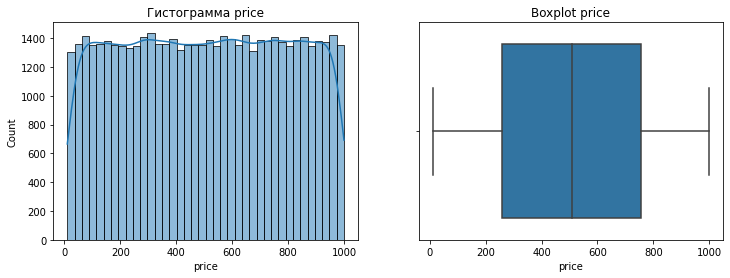

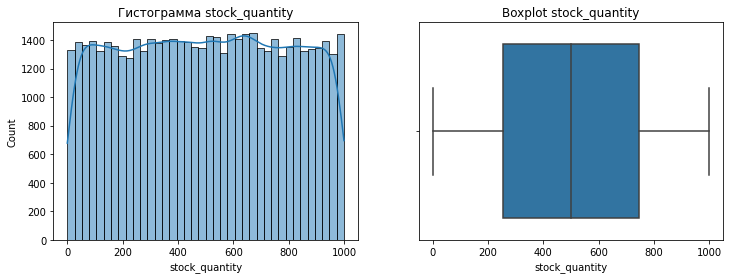


Корреляционная матрица:


,price,stock_quantity
price,1.000000,0.000815
stock_quantity,0.000815,1.000000


In [10]:
# Пример для products
eda(data['products'], ['price', 'stock_quantity'])

# Корреляция
corr = data['products'][['price', 'stock_quantity']].corr()
print("\nКорреляционная матрица:")
display(corr)

### Выгрузка обработанных данных

In [11]:
output_dir = 'exported_csv'
os.makedirs(output_dir, exist_ok=True)

In [12]:
# Фильтрация по дате: только заказы с 01.01.2025 по 01.06.2025
orders_filtered = data['orders'][
    (data['orders']['order_date'] >= '2025-01-01') &
    (data['orders']['order_date'] <= '2025-06-01')
]

orders_path = os.path.join(output_dir, 'orders_filtered.csv')
orders_filtered.to_csv(orders_path, sep=";", index=False)

print(f"Таблица заказов успешно выгружена: {orders_path}")
print(f"Строк: {orders_filtered.shape[0]}, Колонок: {orders_filtered.shape[1]}")

Таблица заказов успешно выгружена: exported_csv/orders_filtered.csv
Строк: 246456, Колонок: 5


Была проведена предобработка данных для дальнейшей работы. Данные очищены от дубликатов, пропуски обработаны, исправили ошибки и преобразованы типы данных. Параллельно сделан исследовательский анализ: изучены распределения признаков, проведен корреляционный анализ.